**Mini Project**

# Project Title:Hospital Patient Record Analysis using Python (Real-World Dirty Dataset)

Dataset: Hospital Records for Data Cleaning (Medium)

**Step 1: Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 2: Load Dataset**

In [4]:
df=pd.read_csv("./drive/MyDrive/Data/hospital_patients_real_world.csv")

In [5]:
df

,PatientID,Age,Gender,Diagnosis,AdmissionDate,DischargeDate,HospitalID
0,PN-2021066,7.0,Other,Myocardial Infarction,2024-03-23,2024-03-29,HOSP-65
1,PN-4606019,36.0,Other,Pneumonia,2024-08-01,2024-08-07,HOSP-79
2,PN-2594016,70.0,Other,Influenza,2024-11-16,2024-11-23,HOSP-27
3,PN-6906914,90.0,Unknown,Acute Bronchitis,2025-07-05,2025-07-10,HOSP-64
4,PN-4656204,0.0,Female,Type 2 Diabetes,2023-08-30,2023-08-31,HOSP-31
...,...,...,...,...,...,...,...
4995,PN-3536392,22.0,Female,NaN,2024-03-14,2024-03-18,HOSP-14
4996,PN-8451961,NaN,Other,Myocardial Infarction,2025-03-20,2025-03-21,HOSP-29
4997,PN-3076032,0.0,Male,Urinary Tract Infection,2023-10-28,2023-10-31,HOSP-83
4998,PN-1714852,29.0,Other,Urinary Tract Infection,2024-08-09,2024-08-16,HOSP-64


**Step 3: Basic Exploration**

In [6]:
# First 5 rows
print(df.head())

# Dataset shape
print("Shape:", df.shape)

# Column names
print("Columns:", df.columns)

# Data types
print(df.dtypes)

# Summary
print(df.info())

    PatientID   Age   Gender              Diagnosis AdmissionDate  \
0  PN-2021066   7.0    Other  Myocardial Infarction    2024-03-23   
1  PN-4606019  36.0    Other              Pneumonia    2024-08-01   
2  PN-2594016  70.0    Other              Influenza    2024-11-16   
3  PN-6906914  90.0  Unknown       Acute Bronchitis    2025-07-05   
4  PN-4656204   0.0   Female        Type 2 Diabetes    2023-08-30   

  DischargeDate HospitalID  
0    2024-03-29    HOSP-65  
1    2024-08-07    HOSP-79  
2    2024-11-23    HOSP-27  
3    2025-07-10    HOSP-64  
4    2023-08-31    HOSP-31  
Shape: (5000, 7)
Columns: Index(['PatientID', 'Age', 'Gender', 'Diagnosis', 'AdmissionDate',
       'DischargeDate', 'HospitalID'],
      dtype='object')
PatientID         object
Age              float64
Gender            object
Diagnosis         object
AdmissionDate     object
DischargeDate     object
HospitalID        object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to

**Step 4: Check Missing Values**

In [7]:
print(df.isnull().sum())

PatientID          0
Age              350
Gender           350
Diagnosis        350
AdmissionDate      0
DischargeDate      0
HospitalID         0
dtype: int64


**Step 5: Handle Missing Values**

In [8]:
#Age → Fill using median
df["Age"] = df["Age"].fillna(df["Age"].median())

In [9]:
#Gender → Fill using mode
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [10]:
#Diagnosis → Fill using Unknown
df["Diagnosis"] = df["Diagnosis"].fillna("Unknown")

**Step 6: Check Duplicate Records**

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

Duplicate Rows: 0


**Step 7: Convert Date Columns**

In [12]:
df["AdmissionDate"] = pd.to_datetime(df["AdmissionDate"])
df["DischargeDate"] = pd.to_datetime(df["DischargeDate"])

**Step 8: Remove Invalid Date Records**

In [13]:
df = df[df["DischargeDate"] >= df["AdmissionDate"]]

**Step 9: Handle Age Outliers**

In [14]:
print(df["Age"].describe())

count    4850.000000
mean       47.251753
std        26.945266
min         0.000000
25%        24.000000
50%        47.000000
75%        70.000000
max        95.000000
Name: Age, dtype: float64


**Step 10: Final Clean Check**

In [15]:
print(df.info())
print(df.head())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 4850 entries, 0 to 4998
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   PatientID      4850 non-null   object        
 1   Age            4850 non-null   float64       
 2   Gender         4850 non-null   object        
 3   Diagnosis      4850 non-null   object        
 4   AdmissionDate  4850 non-null   datetime64[ns]
 5   DischargeDate  4850 non-null   datetime64[ns]
 6   HospitalID     4850 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 303.1+ KB
None
    PatientID   Age   Gender              Diagnosis AdmissionDate  \
0  PN-2021066   7.0    Other  Myocardial Infarction    2024-03-23   
1  PN-4606019  36.0    Other              Pneumonia    2024-08-01   
2  PN-2594016  70.0    Other              Influenza    2024-11-16   
3  PN-6906914  90.0  Unknown       Acute Bronchitis    2025-07-05   
4  PN-4656204   0

**Feature Engineering + EDA Preparation.**

*Step 11: Create Stay Duration Column*

Let's see how many days patient stayed from the admission date to the discharge date.

In [16]:
df["Stay_Duration"] = (df["DischargeDate"] - df["AdmissionDate"]).dt.days

**Step 12: Create Age Group Column**

Patients split into the basis of Age group

In [17]:
bins = [0, 18, 59, 100]
labels = ["Child", "Adult", "Senior"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [18]:
print(df[["Age", "Age_Group"]].head())

    Age Age_Group
0   7.0     Child
1  36.0     Adult
2  70.0    Senior
3  90.0    Senior
4   0.0       NaN


**Step 13: Create Admission Month Column**

Analyse Month-wise trend.

In [19]:
df["Admission_Month"] = df["AdmissionDate"].dt.month_name()

In [20]:
print(df[["AdmissionDate", "Admission_Month"]].head())

  AdmissionDate Admission_Month
0    2024-03-23           March
1    2024-08-01          August
2    2024-11-16        November
3    2025-07-05            July
4    2023-08-30          August


**Step 14: Final Feature Check**

In [21]:
print(df.head())

    PatientID   Age   Gender              Diagnosis AdmissionDate  \
0  PN-2021066   7.0    Other  Myocardial Infarction    2024-03-23   
1  PN-4606019  36.0    Other              Pneumonia    2024-08-01   
2  PN-2594016  70.0    Other              Influenza    2024-11-16   
3  PN-6906914  90.0  Unknown       Acute Bronchitis    2025-07-05   
4  PN-4656204   0.0   Female        Type 2 Diabetes    2023-08-30   

  DischargeDate HospitalID  Stay_Duration Age_Group Admission_Month  
0    2024-03-29    HOSP-65              6     Child           March  
1    2024-08-07    HOSP-79              6     Adult          August  
2    2024-11-23    HOSP-27              7    Senior        November  
3    2025-07-10    HOSP-64              5    Senior            July  
4    2023-08-31    HOSP-31              1       NaN          August  


**EDA**

**Step 15: Age Distribution**

Using Histogram

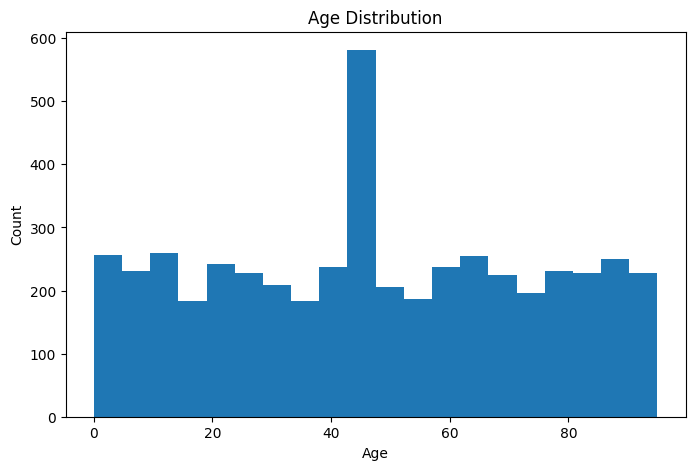

In [22]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

**Step 16: Gender Distribution**

**Bar chart. **

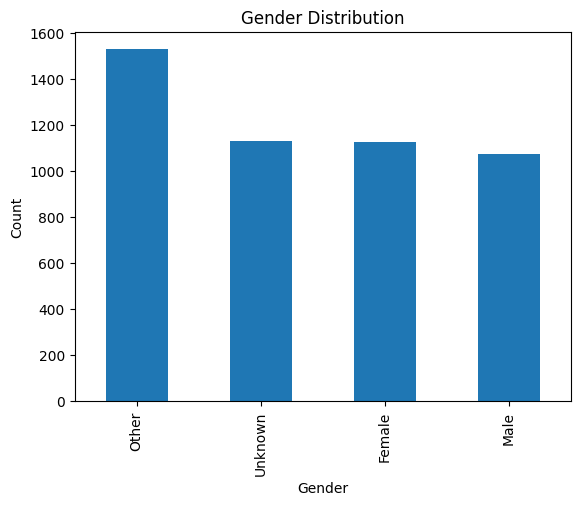

In [23]:
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

**Step 17: Age Group Distribution**

**Pie chart.**

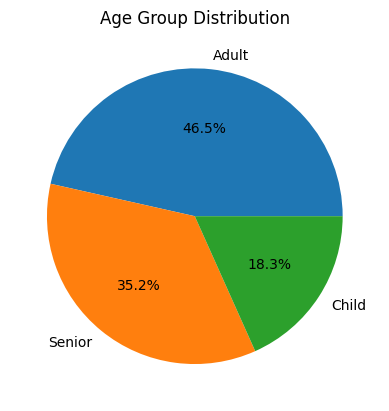

In [24]:
df["Age_Group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Age Group Distribution")
plt.ylabel("")
plt.show()

**Step 18: Most Common Diagnosis**

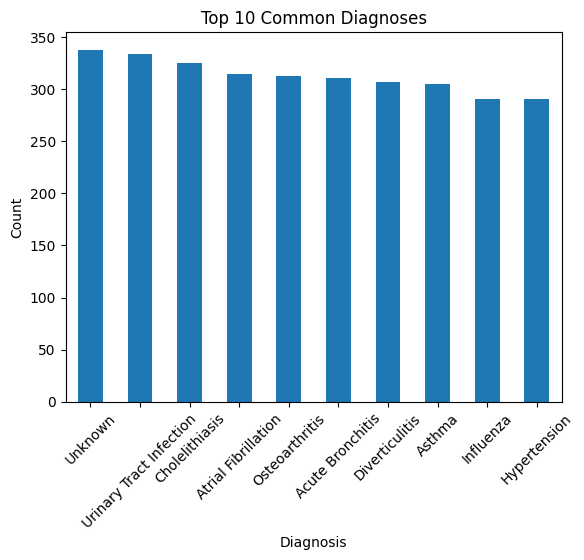

In [25]:
df["Diagnosis"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Common Diagnoses")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**Step 19: Monthly Admissions Trend**

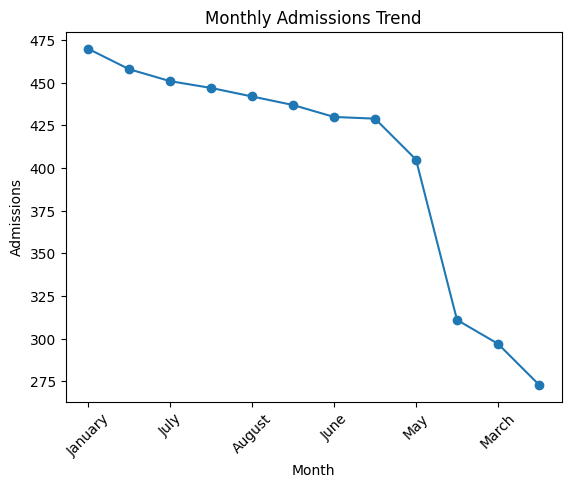

In [26]:
monthly_admissions = df["Admission_Month"].value_counts()

monthly_admissions.plot(kind="line", marker="o")
plt.title("Monthly Admissions Trend")
plt.xlabel("Month")
plt.ylabel("Admissions")
plt.xticks(rotation=45)
plt.show()

**Step 20: Hospital-wise Patient Count**

**Bar chart.**

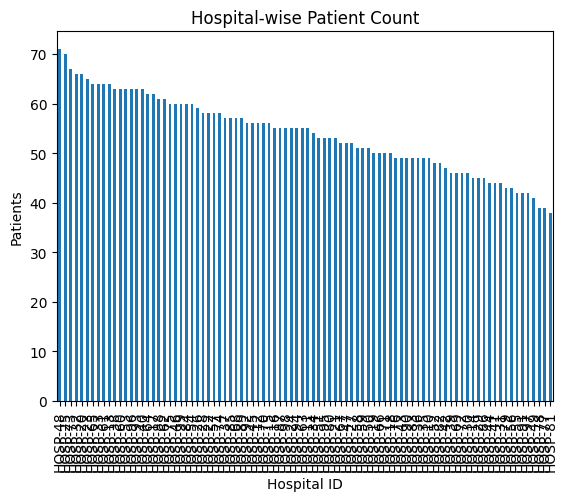

In [27]:
df["HospitalID"].value_counts().plot(kind="bar")
plt.title("Hospital-wise Patient Count")
plt.xlabel("Hospital ID")
plt.ylabel("Patients")
plt.show()

**Step 21: Stay Duration Distribution**

Let's analyze how many days patients were admitted.

Insight: Mostly we see whether patients have a short stay or a long stay.

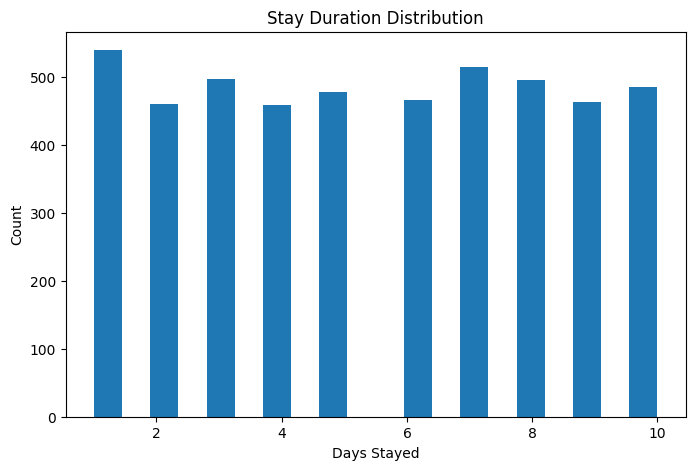

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df["Stay_Duration"], bins=20)
plt.title("Stay Duration Distribution")
plt.xlabel("Days Stayed")
plt.ylabel("Count")
plt.show()

**Step 22: Average Stay Duration**

In [29]:
print("Average Stay Duration:", df["Stay_Duration"].mean())

Average Stay Duration: 5.466185567010309


**Step 23: Long Stay Patients**

(Ex: stay more than 10 days)

In [30]:
long_stay = df[df["Stay_Duration"] > 10]
print("Long Stay Patients Count:", len(long_stay))

Long Stay Patients Count: 0


**Step 24: Stay Duration Outliers (Box Plot)**

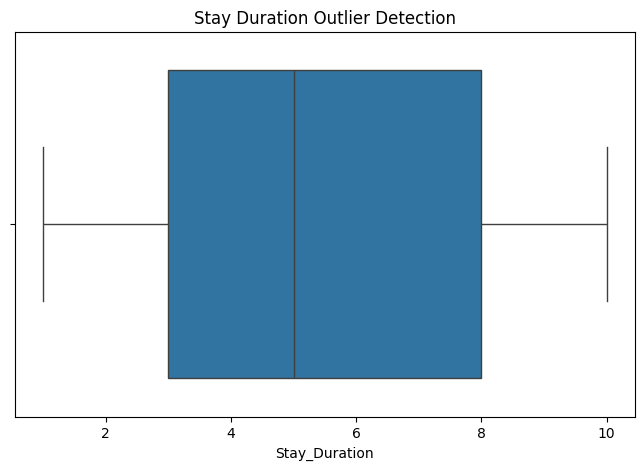

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Stay_Duration"])
plt.title("Stay Duration Outlier Detection")
plt.show()

**Step 25: Age Group vs Diagnosis (Heatmap)**

Which diagnosis is more common in which age group.

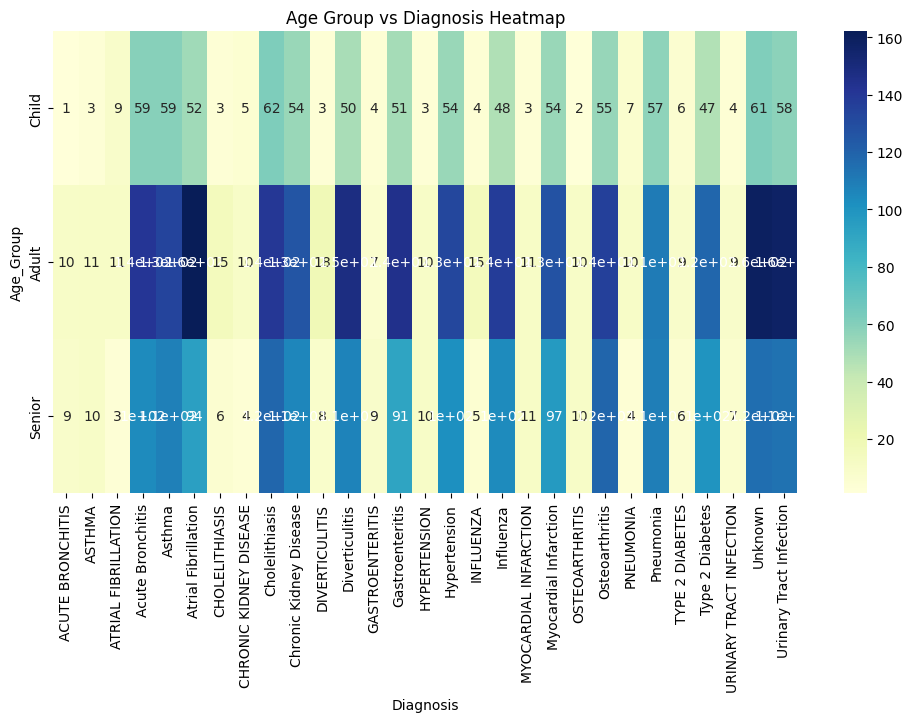

In [32]:
cross_tab = pd.crosstab(df["Age_Group"], df["Diagnosis"])

plt.figure(figsize=(12,6))
sns.heatmap(cross_tab, annot=True, cmap="YlGnBu")
plt.title("Age Group vs Diagnosis Heatmap")
plt.show()

**Step 26: Hospital vs Diagnosis (Heatmap)**

Which hospital has the most diagnoses?

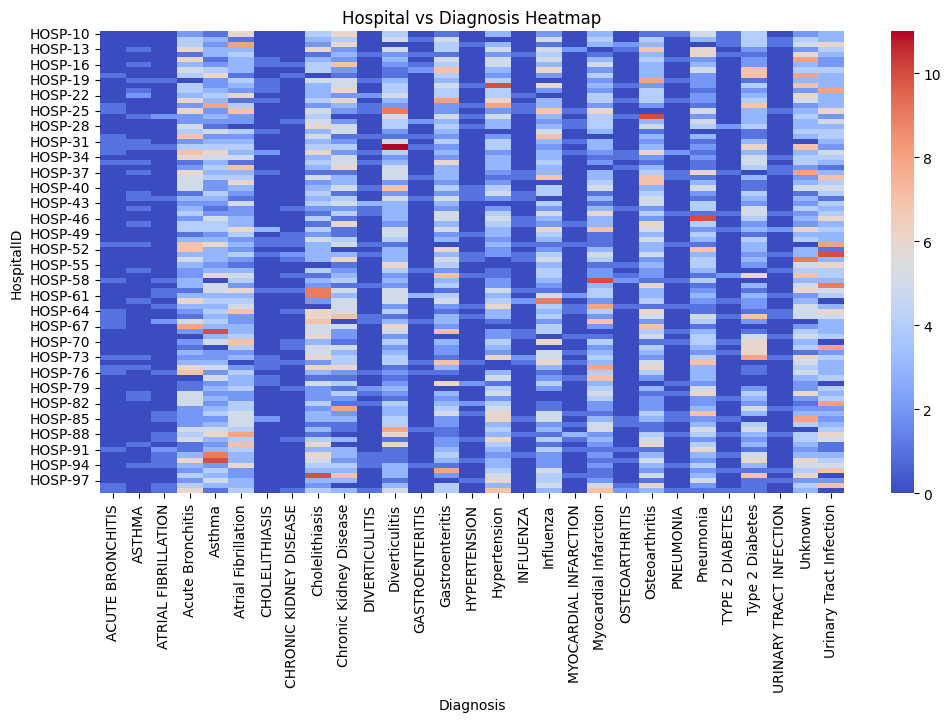

In [33]:
hospital_diag = pd.crosstab(df["HospitalID"], df["Diagnosis"])

plt.figure(figsize=(12,6))
sns.heatmap(hospital_diag, cmap="coolwarm")
plt.title("Hospital vs Diagnosis Heatmap")
plt.show()

**Step 27: Save Clean Dataset**

In [7]:
df.to_csv("clean_hospital_patients.csv", index=False)
from google.colab import files
files.download("clean_hospital_patients.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Step 28: Conclusion**

This project analyzed a real-world dirty hospital patient dataset using Python. Data cleaning, feature engineering, exploratory data analysis, and visualization were performed to identify patient demographics, diagnosis trends, admission patterns, hospital workload, and stay duration insights. This project demonstrates practical healthcare analytics and real-world data handling skills.